MANGO GRADING SYSTEM - ULTIMATE VERSION

[1/5] Loading data...


[ WARN:0@1022.825] global loadsave.cpp:278 findDecoder imread_('images/149b.jpg'): can't open/read file: check file path/integrity
[ WARN:0@1022.976] global loadsave.cpp:278 findDecoder imread_('images/167b.jpg'): can't open/read file: check file path/integrity


✓ Loaded 272 samples

[2/5] Encoding labels...
✓ Ripeness: ['K' 'P']
✓ Grade: ['1' '2' 'P']

[3/5] K-Fold Cross-Validation (Anti-Overfitting)...


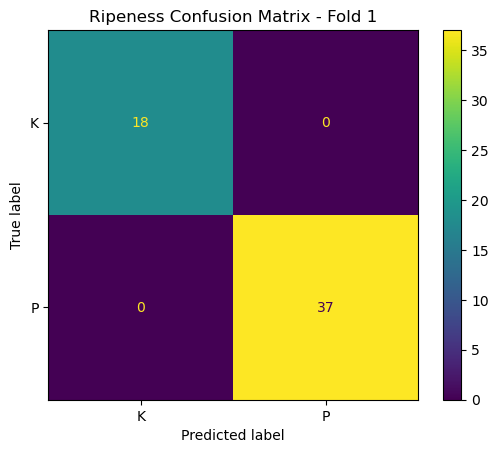

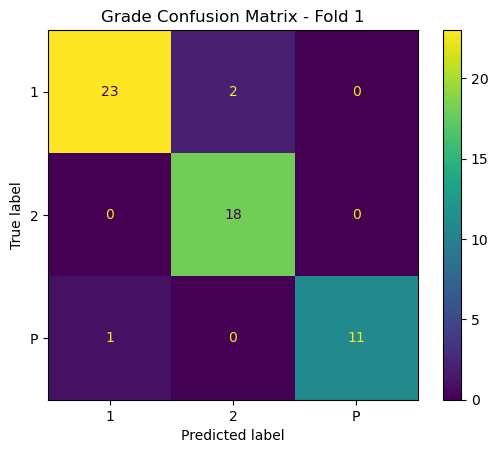

  Fold 1/5: Rip F1=1.000, Grade F1=0.945


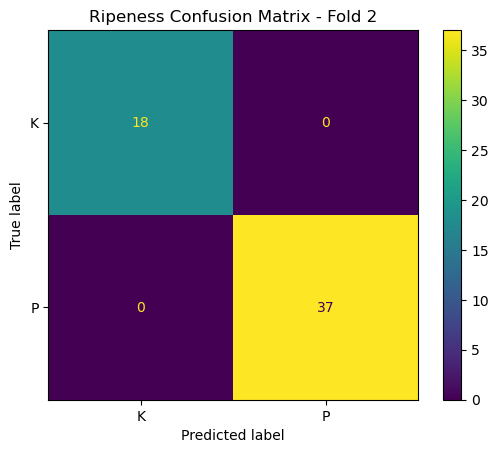

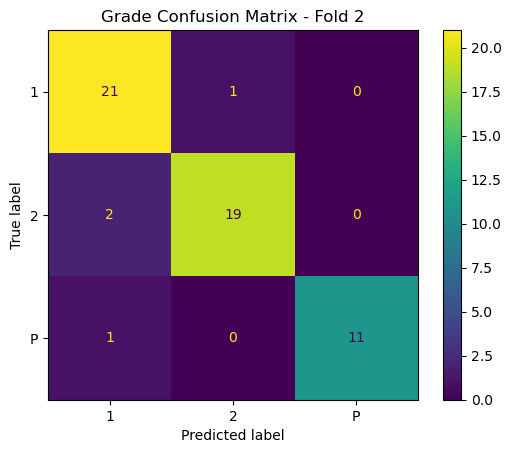

  Fold 2/5: Rip F1=1.000, Grade F1=0.928


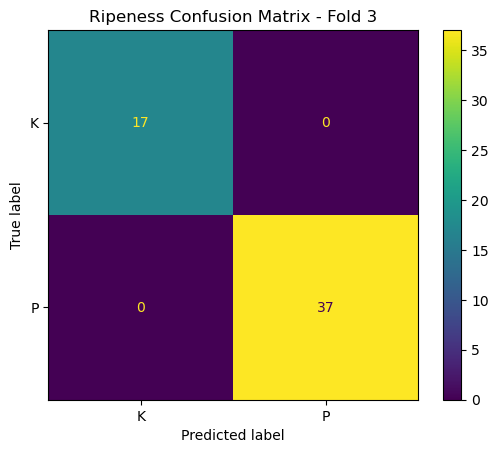

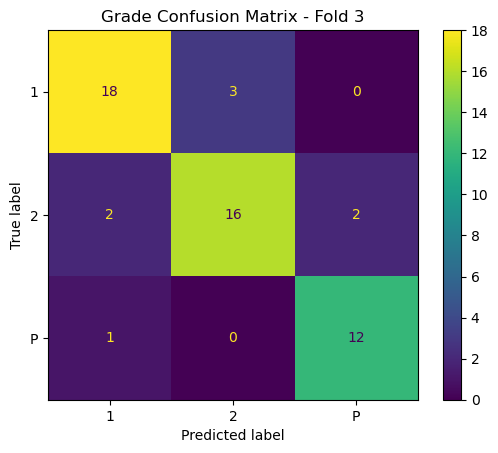

  Fold 3/5: Rip F1=1.000, Grade F1=0.851


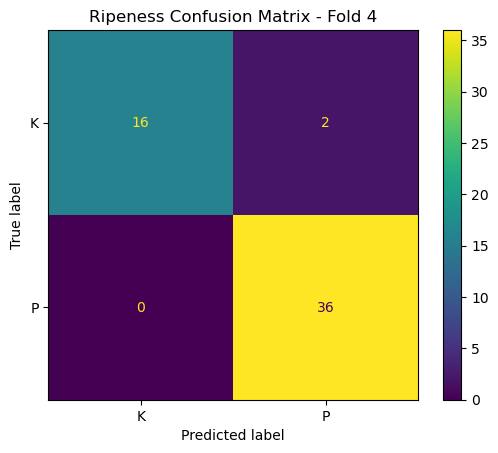

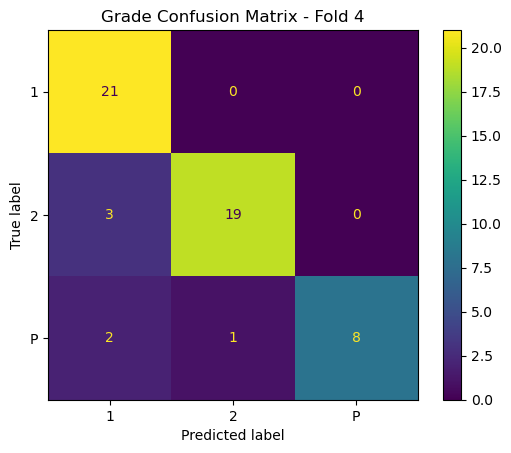

  Fold 4/5: Rip F1=0.962, Grade F1=0.888


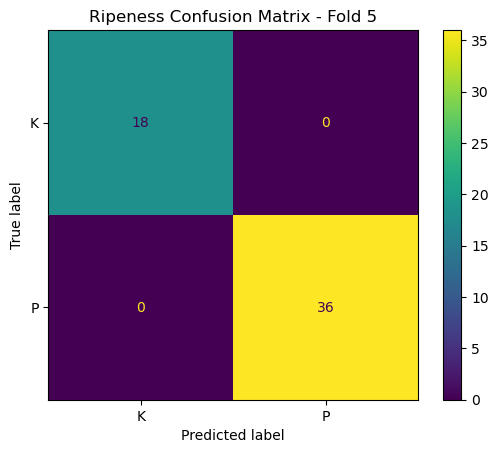

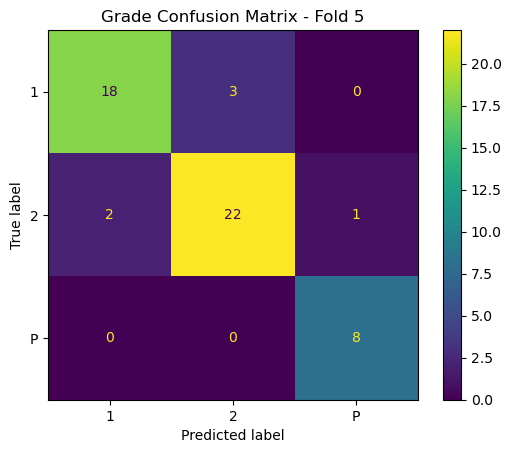

  Fold 5/5: Rip F1=1.000, Grade F1=0.888

CROSS-VALIDATION RESULTS

🍋 RIPENESS (5-Fold CV):
   Accuracy:  0.9926 ± 0.0148
   Precision: 0.9930 ± 0.0140
   Recall:    0.9926 ± 0.0148
   F1-Score:  0.9925 ± 0.0151

🏆 GRADE (5-Fold CV):
   Accuracy:  0.9005 ± 0.0328
   Precision: 0.9050 ± 0.0336
   Recall:    0.9005 ± 0.0328
   F1-Score:  0.9001 ± 0.0332

[4/5] Training final model on all data...
✓ Final models trained


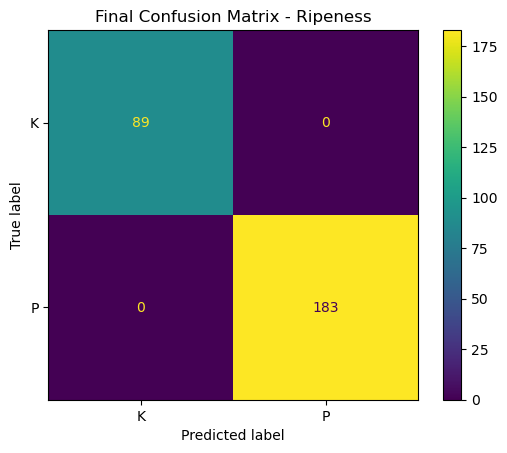

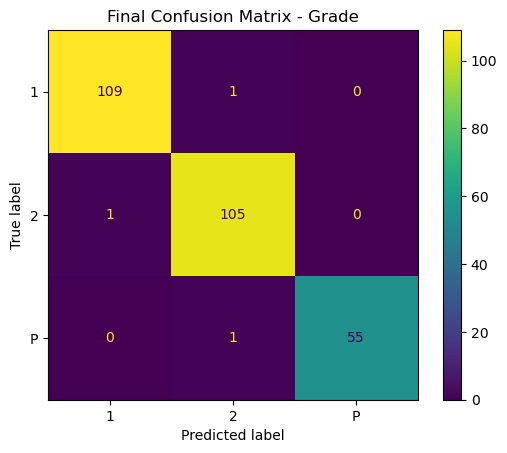


[5/5] System ready!

Usage: predict_mango('front.jpg', 'back.jpg', 450)


In [2]:
# ==========================================
# MANGO ANALYSIS SYSTEM - ULTIMATE VERSION
# Combining Best Validation + K-Fold CV
# ==========================================

import os
import cv2
import numpy as np
import pandas as pd
import warnings

from skimage.feature import graycomatrix, graycoprops
from skimage.metrics import structural_similarity as ssim
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupShuffleSplit, StratifiedKFold
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.ensemble import GradientBoostingClassifier

warnings.filterwarnings("ignore")

print("="*70)
print("MANGO GRADING SYSTEM - ULTIMATE VERSION")
print("="*70)

IMAGE_DIR = "images"
EXCEL_PATH = "Harumanis_mango_weight_grade.xlsx"

# ==========================================
# SEGMENTATION (FROM YOUR CODE)
# ==========================================

def segment_mango(img):
    """Remove background, isolate mango"""
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    lower = np.array([15, 30, 30])
    upper = np.array([95, 255, 255])
    mask = cv2.inRange(hsv, lower, upper)
    kernel = np.ones((7, 7), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mango = cv2.bitwise_and(img, img, mask=mask)
    return mango, mask


# ==========================================
# VALIDATION FUNCTIONS (ENHANCED)
# ==========================================

def check_blur(img):
    """Detect blurry images"""
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur_score = cv2.Laplacian(gray, cv2.CV_64F).var()
    return blur_score < 35, blur_score


def check_exact_duplicate(img1, img2):
    """
    NEW: Check if images are EXACT duplicates (same photo)
    Uses SSIM on full images before segmentation
    """
    gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

    if gray1.shape != gray2.shape:
        gray2 = cv2.resize(gray2, (gray1.shape[1], gray1.shape[0]))

    ssim_score, _ = ssim(gray1, gray2, full=True)

    # If SSIM > 0.95, images are duplicates
    return ssim_score > 0.95, ssim_score


def check_same_mango(img1, img2):
    """
    YOUR CODE: Multi-check validation
    Returns True if SAME mango, False if DIFFERENT
    """
    mango1, _ = segment_mango(img1)
    mango2, _ = segment_mango(img2)

    # 1. Histogram similarity
    hsv1 = cv2.cvtColor(mango1, cv2.COLOR_BGR2HSV)
    hsv2 = cv2.cvtColor(mango2, cv2.COLOR_BGR2HSV)

    hist1 = cv2.calcHist([hsv1], [0, 1], None, [50, 60], [0, 180, 0, 256])
    hist2 = cv2.calcHist([hsv2], [0, 1], None, [50, 60], [0, 180, 0, 256])

    cv2.normalize(hist1, hist1)
    cv2.normalize(hist2, hist2)

    hist_sim = cv2.compareHist(hist1, hist2, cv2.HISTCMP_CORREL)

    # 2. Structural similarity
    g1 = cv2.cvtColor(mango1, cv2.COLOR_BGR2GRAY)
    g2 = cv2.cvtColor(mango2, cv2.COLOR_BGR2GRAY)
    g2 = cv2.resize(g2, (g1.shape[1], g1.shape[0]))

    ssim_score, _ = ssim(g1, g2, full=True)

    # 3. ORB feature matching
    orb = cv2.ORB_create()
    kp1, des1 = orb.detectAndCompute(g1, None)
    kp2, des2 = orb.detectAndCompute(g2, None)

    matches = 0
    if des1 is not None and des2 is not None:
        bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
        matches = len(bf.match(des1, des2))

    # Decision: ALL 3 checks must pass
    is_same = (hist_sim >= 0.85 and ssim_score >= 0.75 and matches >= 8)

    return is_same, {
        'hist_sim': hist_sim,
        'ssim': ssim_score,
        'orb_matches': matches
    }


def check_weight(weight):
    """Validate weight range"""
    return 300 <= weight <= 700


# ==========================================
# FEATURE EXTRACTION
# ==========================================

def extract_image_features(img):
    
    img = cv2.resize(img, (224, 224))

    rgb_mean = img.mean(axis=(0, 1))
    rgb_std = img.std(axis=(0, 1))

    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    hsv_mean = hsv.mean(axis=(0, 1))
    hsv_std = hsv.std(axis=(0, 1))

    hue = hsv[:, :, 0]
    hue_hist, _ = np.histogram(hue, bins=16, range=(0, 180))
    hue_hist = hue_hist / (hue_hist.sum() + 1e-10)

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray_r = (gray / 4).astype(np.uint8)

    glcm = graycomatrix(gray_r, [1], [0, np.pi/4, np.pi/2, 3*np.pi/4],
                        levels=64, symmetric=True, normed=True)

    texture = [graycoprops(glcm, p).mean()
               for p in ["contrast", "homogeneity", "energy", "correlation", "dissimilarity"]]

    return np.hstack([rgb_mean, rgb_std, hsv_mean, hsv_std, hue_hist, texture])


# ==========================================
# LOAD & PREPARE DATA
# ==========================================

print("\n[1/5] Loading data...")

df = pd.read_excel(EXCEL_PATH)
df["Fruit Grade"] = df["Fruit Grade"].astype(str)
df["Fruit_ID"] = df["Fruit No"].str.extract(r"(\d+)")

X_img, X_weight, y_rip, y_grd, groups = [], [], [], [], []

for fid, g in df.groupby("Fruit_ID"):
    if len(g) != 2:
        continue
    r1, r2 = g.iloc[0], g.iloc[1]

    img1 = cv2.imread(os.path.join(IMAGE_DIR, r1["Fruit No"]))
    img2 = cv2.imread(os.path.join(IMAGE_DIR, r2["Fruit No"]))

    if img1 is None or img2 is None:
        continue

    f1 = extract_image_features(img1)
    f2 = extract_image_features(img2)
    feat = (f1 + f2) / 2

    X_img.append(feat)
    X_weight.append([r1["Mass(kg)"]])
    y_rip.append(r1["Color_K-Yellow_P_Green"])
    y_grd.append(r1["Fruit Grade"])
    groups.append(fid)

X = np.hstack([np.array(X_img), np.array(X_weight)])
groups = np.array(groups)

print(f"✓ Loaded {len(X)} samples")

# ==========================================
# ENCODE LABELS
# ==========================================

print("\n[2/5] Encoding labels...")

rip_enc = LabelEncoder()
grd_enc = LabelEncoder()

y_rip = rip_enc.fit_transform(y_rip)
y_grd = grd_enc.fit_transform(y_grd)

print(f"✓ Ripeness: {rip_enc.classes_}")
print(f"✓ Grade: {grd_enc.classes_}")

# ==========================================
# K-FOLD CROSS-VALIDATION (FIXED OVERFITTING)
# ==========================================

print("\n[3/5] K-Fold Cross-Validation (Anti-Overfitting)...")

n_splits = 5
kfold = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

cv_results_rip = []
cv_results_grd = []

for fold, (train_idx, test_idx) in enumerate(kfold.split(X, y_rip), 1):
    X_train, X_test = X[train_idx], X[test_idx]
    yr_train, yr_test = y_rip[train_idx], y_rip[test_idx]
    yg_train, yg_test = y_grd[train_idx], y_grd[test_idx]

    # Scale
    scaler = RobustScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    # Train (with anti-overfitting params)
    gb_rip = GradientBoostingClassifier(
        n_estimators=50, learning_rate=0.05, max_depth=3,
        min_samples_split=10, min_samples_leaf=5,
        subsample=0.8, random_state=42
    )
    gb_grd = GradientBoostingClassifier(
        n_estimators=50, learning_rate=0.05, max_depth=3,
        min_samples_split=10, min_samples_leaf=5,
        subsample=0.8, random_state=42
    )

    gb_rip.fit(X_train_s, yr_train)
    gb_grd.fit(X_train_s, yg_train)

    # Evaluate
    yr_pred = gb_rip.predict(X_test_s)
    yg_pred = gb_grd.predict(X_test_s)
    # ==========================
# CONFUSION MATRIX (PER FOLD)
# ==========================

# Ripeness
    cm_rip = confusion_matrix(yr_test, yr_pred)
    disp_rip = ConfusionMatrixDisplay(
        confusion_matrix=cm_rip,
        display_labels=rip_enc.classes_
    )
    disp_rip.plot()
    plt.title(f"Ripeness Confusion Matrix - Fold {fold}")
    plt.show()
    
    # Grade
    cm_grd = confusion_matrix(yg_test, yg_pred)
    disp_grd = ConfusionMatrixDisplay(
        confusion_matrix=cm_grd,
        display_labels=grd_enc.classes_
    )
    disp_grd.plot()
    plt.title(f"Grade Confusion Matrix - Fold {fold}")
    plt.show()
    cv_results_rip.append({
        'fold': fold,
        'acc': accuracy_score(yr_test, yr_pred),
        'prec': precision_score(yr_test, yr_pred, average='weighted', zero_division=0),
        'rec': recall_score(yr_test, yr_pred, average='weighted', zero_division=0),
        'f1': f1_score(yr_test, yr_pred, average='weighted', zero_division=0)
    })

    cv_results_grd.append({
        'fold': fold,
        'acc': accuracy_score(yg_test, yg_pred),
        'prec': precision_score(yg_test, yg_pred, average='weighted', zero_division=0),
        'rec': recall_score(yg_test, yg_pred, average='weighted', zero_division=0),
        'f1': f1_score(yg_test, yg_pred, average='weighted', zero_division=0)
    })

    print(f"  Fold {fold}/5: Rip F1={cv_results_rip[-1]['f1']:.3f}, Grade F1={cv_results_grd[-1]['f1']:.3f}")

# Calculate averages
avg_rip = {k: np.mean([r[k] for r in cv_results_rip]) for k in ['acc', 'prec', 'rec', 'f1']}
avg_grd = {k: np.mean([r[k] for r in cv_results_grd]) for k in ['acc', 'prec', 'rec', 'f1']}

std_rip = {k: np.std([r[k] for r in cv_results_rip]) for k in ['acc', 'prec', 'rec', 'f1']}
std_grd = {k: np.std([r[k] for r in cv_results_grd]) for k in ['acc', 'prec', 'rec', 'f1']}

print("\n" + "="*70)
print("CROSS-VALIDATION RESULTS")
print("="*70)
print(f"\n🍋 RIPENESS (5-Fold CV):")
print(f"   Accuracy:  {avg_rip['acc']:.4f} ± {std_rip['acc']:.4f}")
print(f"   Precision: {avg_rip['prec']:.4f} ± {std_rip['prec']:.4f}")
print(f"   Recall:    {avg_rip['rec']:.4f} ± {std_rip['rec']:.4f}")
print(f"   F1-Score:  {avg_rip['f1']:.4f} ± {std_rip['f1']:.4f}")

print(f"\n🏆 GRADE (5-Fold CV):")
print(f"   Accuracy:  {avg_grd['acc']:.4f} ± {std_grd['acc']:.4f}")
print(f"   Precision: {avg_grd['prec']:.4f} ± {std_grd['prec']:.4f}")
print(f"   Recall:    {avg_grd['rec']:.4f} ± {std_grd['rec']:.4f}")
print(f"   F1-Score:  {avg_grd['f1']:.4f} ± {std_grd['f1']:.4f}")
print("="*70)

# ==========================================
# TRAIN FINAL MODEL (ON ALL DATA)
# ==========================================

print("\n[4/5] Training final model on all data...")

final_scaler = RobustScaler()
X_final = final_scaler.fit_transform(X)

final_gb_rip = GradientBoostingClassifier(
    n_estimators=50, learning_rate=0.05, max_depth=3,
    min_samples_split=10, min_samples_leaf=5,
    subsample=0.8, random_state=42
)
final_gb_grd = GradientBoostingClassifier(
    n_estimators=50, learning_rate=0.05, max_depth=3,
    min_samples_split=10, min_samples_leaf=5,
    subsample=0.8, random_state=42
)

final_gb_rip.fit(X_final, y_rip)
final_gb_grd.fit(X_final, y_grd)

print("✓ Final models trained")
# ==========================
# FINAL CONFUSION MATRIX
# ==========================

yr_final_pred = final_gb_rip.predict(X_final)
yg_final_pred = final_gb_grd.predict(X_final)

# Ripeness Final
cm_rip_final = confusion_matrix(y_rip, yr_final_pred)
disp_rip_final = ConfusionMatrixDisplay(
    confusion_matrix=cm_rip_final,
    display_labels=rip_enc.classes_
)
disp_rip_final.plot()
plt.title("Final Confusion Matrix - Ripeness")
plt.show()

# Grade Final
cm_grd_final = confusion_matrix(y_grd, yg_final_pred)
disp_grd_final = ConfusionMatrixDisplay(
    confusion_matrix=cm_grd_final,
    display_labels=grd_enc.classes_
)
disp_grd_final.plot()
plt.title("Final Confusion Matrix - Grade")
plt.show()
# ==========================================
# PRICE DECISION (ADDED FROM MISSING)
# ==========================================

def price_decision(grade, ripeness, weight):
    """Calculate market price in RM"""
    if grade == "P" and ripeness == "K":
        price = 40
    elif grade == "P" and ripeness == "P":
        price = 35
    elif grade == "1" and ripeness == "K":
        price = 28
    elif grade == "1" and ripeness == "P":
        price = 24
    elif grade == "2" and ripeness == "K":
        price = 18
    else:
        price = 15

    if weight > 550:
        price += 5
    if weight < 350:
        price -= 3

    return price


# ==========================================
# PREDICTION FUNCTION (ULTIMATE)
# ==========================================

def predict_mango(front, back, weight=None):
    """
    Ultimate prediction with comprehensive validation
    """

    print("\n" + "="*70)
    print("🍋 MANGO ANALYSIS")
    print("="*70)

    # Get weight
    if weight is None:
        weight = float(input("\nWeight (grams): "))

    if not check_weight(weight):
        print("❌ Invalid weight (300-700g required)")
        return

    # Load images
    img1 = cv2.imread(front)
    img2 = cv2.imread(back)

    if img1 is None or img2 is None:
        print("❌ Cannot load images")
        return

    img1 = cv2.resize(img1, (224, 224))
    img2 = cv2.resize(img2, (224, 224))

    # 1. Blur check
    is_blur1, score1 = check_blur(img1)
    is_blur2, score2 = check_blur(img2)

    if is_blur1 or is_blur2:
        print(f"❌ Blurry image detected (scores: {score1:.1f}, {score2:.1f})")
        return

    # 2. Exact duplicate check (NEW)
    is_dup, dup_score = check_exact_duplicate(img1, img2)

    if is_dup:
        print(f"❌ Images are duplicates (SSIM: {dup_score:.3f})")
        print("   Upload front AND back views")
        return

    # 3. Same mango check (YOUR CODE)
    is_same, details = check_same_mango(img1, img2)

    if not is_same:
        print(f"❌ Images from DIFFERENT mangoes")
        print(f"   Hist: {details['hist_sim']:.2f}, SSIM: {details['ssim']:.2f}, ORB: {details['orb_matches']}")
        return

    print("✓ Validation passed")

    # Extract features
    f1 = extract_image_features(img1)
    f2 = extract_image_features(img2)
    feat = (f1 + f2) / 2

    X_input = np.hstack([feat, [weight]]).reshape(1, -1)
    X_input = final_scaler.transform(X_input)

    # Predict
    rip_pred = final_gb_rip.predict(X_input)
    grd_pred = final_gb_grd.predict(X_input)

    ripeness = rip_enc.inverse_transform(rip_pred)[0]
    grade = grd_enc.inverse_transform(grd_pred)[0]

    price = price_decision(grade, ripeness, weight)

    print(f"\nRipeness: {ripeness}")
    print(f"Grade: {grade}")
    print(f"Price: RM {price}")
    print("="*70)


# ==========================================
# READY
# ==========================================

print("\n[5/5] System ready!")
print("\nUsage: predict_mango('front.jpg', 'back.jpg', 450)")
print("="*70)


In [31]:
# # TEST WITH YOUR UPLOADED IMAGES:
predict_mango("bright1.jpeg",
               "mango.jpeg")



🍋 MANGO ANALYSIS



Weight (grams):  500


✓ Validation passed

Ripeness: P
Grade: 1
Price: RM 24


In [22]:
def save_pipeline():
    import joblib

    joblib.dump(final_scaler, "scaler.pkl")
    joblib.dump(final_gb_rip, "ripeness_model.pkl")
    joblib.dump(final_gb_grd, "grade_model.pkl")
    joblib.dump(rip_enc, "ripeness_encoder.pkl")
    joblib.dump(grd_enc, "grade_encoder.pkl")

    print("✓ All files saved successfully")

save_pipeline()

✓ All files saved successfully


In [23]:
print("Training feature shape:", X.shape)
print("Sample feature:", X[0])

Training feature shape: (272, 34)
Sample feature: [1.70685059e+02 1.75672762e+02 1.74360840e+02 5.90373815e+01
 4.03388817e+01 4.24482739e+01 9.80039561e+01 2.74509327e+01
 1.79243503e+02 3.87846911e+01 4.53332989e+01 4.20840805e+01
 2.39955357e-02 1.98301977e-03 6.88775510e-02 1.40804369e-01
 2.85993304e-03 1.20575574e-03 2.77024872e-03 3.28842474e-04
 1.57146843e-02 1.23405612e-01 2.14903540e-01 4.00111607e-01
 2.37165179e-03 2.88982781e-04 3.48772321e-04 2.98947704e-05
 2.21001830e+00 8.70614059e-01 2.78584320e-01 9.90499510e-01
 4.01434996e-01 5.00000000e-01]


In [24]:
rip_enc.classes_

array(['K', 'P'], dtype='<U1')

In [25]:
import pandas as pd

df = pd.read_excel("Harumanis_mango_weight_grade.xlsx")

# Clean values (important)
df["Color_K-Yellow_P_Green"] = df["Color_K-Yellow_P_Green"].astype(str).str.strip()
df["Fruit Grade"] = df["Fruit Grade"].astype(str).str.strip()

# Check exact match
result = df[
    (df["Color_K-Yellow_P_Green"] == "K") &
    (df["Fruit Grade"] == "P")
]

print("Total matching rows:", len(result))
display(result.head())

Total matching rows: 10


,Fruit No,Color_K-Yellow_P_Green,Fruit Grade,Mass(kg)
85,86a.jpg,K,P,0.60
88,169a.jpg,K,P,0.56
91,169b.jpg,K,P,0.56
133,233a.jpg,K,P,0.65
138,234a.jpg,K,P,0.65


In [26]:
result = df[
    (df["Color_K-Yellow_P_Green"] == "K") &
    (df["Fruit Grade"] == "1")
]

print("Total matching rows:", len(result))
display(result.head())

Total matching rows: 80


,Fruit No,Color_K-Yellow_P_Green,Fruit Grade,Mass(kg)
82,83a.jpg,K,1,0.65
145,248a.jpg,K,1,0.55
146,255a.jpg,K,1,0.55
169,170a.jpg,K,1,0.40
202,248b.jpg,K,1,0.55


In [32]:
import joblib

joblib.dump(final_gb_rip, "ripeness_model.pkl")
joblib.dump(final_gb_grd, "grade_model.pkl")
joblib.dump(final_scaler, "scaler.pkl")
joblib.dump(rip_enc, "ripeness_encoder.pkl")
joblib.dump(grd_enc, "grade_encoder.pkl")

['grade_encoder.pkl']


[1/4] Loading data...


[ WARN:0@1.961] global loadsave.cpp:278 findDecoder imread_('images/149b.jpg'): can't open/read file: check file path/integrity
[ WARN:0@2.124] global loadsave.cpp:278 findDecoder imread_('images/167b.jpg'): can't open/read file: check file path/integrity


✓ Loaded 272 samples

[2/4] Encoding labels...
Ripeness: ['K' 'P']
Grade: ['1' '2' 'P']

[3/4] Train-Test Split...

[4/4] Evaluation on TEST data...

🍋 RIPENESS METRICS
Accuracy : 0.9818181818181818
Precision: 0.9822966507177033
Recall   : 0.9818181818181818
F1 Score : 0.9816796536796537

🏆 GRADE METRICS
Accuracy : 0.9090909090909091
Precision: 0.9102337662337662
Recall   : 0.9090909090909091
F1 Score : 0.9093082909438721


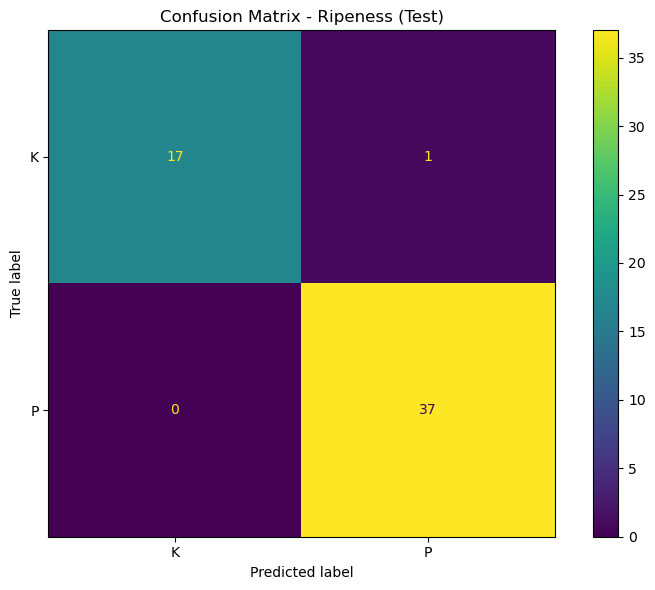

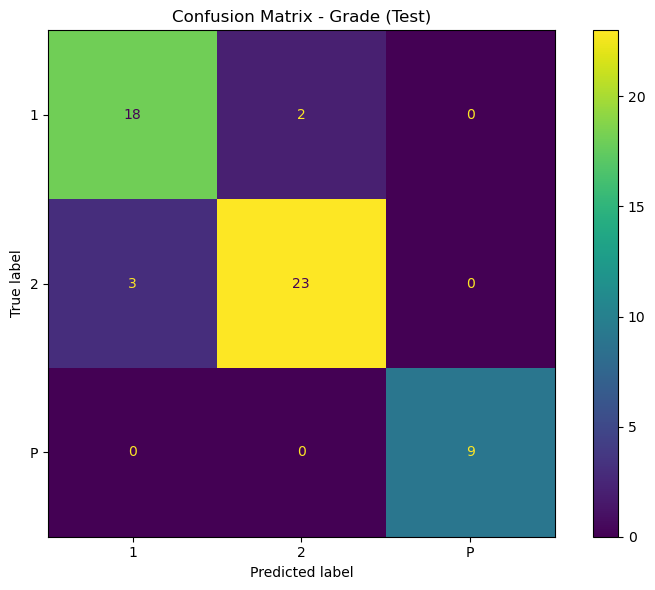


✅ Done! Real evaluation completed.


In [1]:
# ==========================================
# MANGO ANALYSIS SYSTEM - FINAL (CORRECTED)
# Train-Test Split + Real Confusion Matrix
# ==========================================

import os
import cv2
import numpy as np
import pandas as pd
import warnings
import matplotlib.pyplot as plt

from skimage.feature import graycomatrix, graycoprops
from skimage.metrics import structural_similarity as ssim

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import GradientBoostingClassifier

warnings.filterwarnings("ignore")

IMAGE_DIR = "images"
EXCEL_PATH = "Harumanis_mango_weight_grade.xlsx"

# ==========================================
# SEGMENTATION
# ==========================================
def segment_mango(img):
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    lower = np.array([15, 30, 30])
    upper = np.array([95, 255, 255])
    mask = cv2.inRange(hsv, lower, upper)
    kernel = np.ones((7, 7), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mango = cv2.bitwise_and(img, img, mask=mask)
    return mango, mask

# ==========================================
# VALIDATION
# ==========================================
def check_blur(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return cv2.Laplacian(gray, cv2.CV_64F).var() < 35

def check_exact_duplicate(img1, img2):
    g1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
    g2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)
    g2 = cv2.resize(g2, (g1.shape[1], g1.shape[0]))
    score, _ = ssim(g1, g2, full=True)
    return score > 0.95

def check_same_mango(img1, img2):
    mango1, _ = segment_mango(img1)
    mango2, _ = segment_mango(img2)

    hsv1 = cv2.cvtColor(mango1, cv2.COLOR_BGR2HSV)
    hsv2 = cv2.cvtColor(mango2, cv2.COLOR_BGR2HSV)

    hist1 = cv2.calcHist([hsv1],[0,1],None,[50,60],[0,180,0,256])
    hist2 = cv2.calcHist([hsv2],[0,1],None,[50,60],[0,180,0,256])

    cv2.normalize(hist1, hist1)
    cv2.normalize(hist2, hist2)

    hist_sim = cv2.compareHist(hist1, hist2, cv2.HISTCMP_CORREL)

    g1 = cv2.cvtColor(mango1, cv2.COLOR_BGR2GRAY)
    g2 = cv2.cvtColor(mango2, cv2.COLOR_BGR2GRAY)
    g2 = cv2.resize(g2, (g1.shape[1], g1.shape[0]))

    ssim_score, _ = ssim(g1, g2, full=True)

    orb = cv2.ORB_create()
    kp1, des1 = orb.detectAndCompute(g1, None)
    kp2, des2 = orb.detectAndCompute(g2, None)

    matches = 0
    if des1 is not None and des2 is not None:
        bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
        matches = len(bf.match(des1, des2))

    return (hist_sim >= 0.85 and ssim_score >= 0.75 and matches >= 8)

# ==========================================
# FEATURE EXTRACTION
# ==========================================
def extract_features(img):
    img = cv2.resize(img, (224, 224))

    rgb_mean = img.mean(axis=(0,1))
    rgb_std = img.std(axis=(0,1))

    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    hsv_mean = hsv.mean(axis=(0,1))
    hsv_std = hsv.std(axis=(0,1))

    hue = hsv[:,:,0]
    hist,_ = np.histogram(hue, bins=16, range=(0,180))
    hist = hist/(hist.sum()+1e-10)

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray = (gray/4).astype(np.uint8)

    glcm = graycomatrix(gray,[1],[0,np.pi/4,np.pi/2,3*np.pi/4],
                        levels=64, symmetric=True, normed=True)

    texture = [graycoprops(glcm,p).mean()
               for p in ["contrast","homogeneity","energy","correlation","dissimilarity"]]

    return np.hstack([rgb_mean,rgb_std,hsv_mean,hsv_std,hist,texture])

# ==========================================
# LOAD DATA
# ==========================================
print("\n[1/4] Loading data...")

df = pd.read_excel(EXCEL_PATH)
df["Fruit_ID"] = df["Fruit No"].str.extract(r"(\d+)")

X_img, X_w, y_rip, y_grd = [], [], [], []

for fid,g in df.groupby("Fruit_ID"):
    if len(g)!=2: continue

    r1,r2 = g.iloc[0], g.iloc[1]

    img1 = cv2.imread(os.path.join(IMAGE_DIR,r1["Fruit No"]))
    img2 = cv2.imread(os.path.join(IMAGE_DIR,r2["Fruit No"]))

    if img1 is None or img2 is None: continue

    f = (extract_features(img1)+extract_features(img2))/2

    X_img.append(f)
    X_w.append([r1["Mass(kg)"]])
    y_rip.append(r1["Color_K-Yellow_P_Green"])
    y_grd.append(r1["Fruit Grade"])

X = np.hstack([np.array(X_img), np.array(X_w)])

print(f"✓ Loaded {len(X)} samples")

# ==========================================
# ENCODING
# ==========================================
print("\n[2/4] Encoding labels...")

rip_enc = LabelEncoder()
grd_enc = LabelEncoder()

y_rip = rip_enc.fit_transform(y_rip)
y_grd = grd_enc.fit_transform(y_grd)

print("Ripeness:", rip_enc.classes_)
print("Grade:", grd_enc.classes_)

# ==========================================
# TRAIN-TEST SPLIT (FIX)
# ==========================================
print("\n[3/4] Train-Test Split...")

X_train, X_test, y_rip_train, y_rip_test, y_grd_train, y_grd_test = train_test_split(
    X, y_rip, y_grd,
    test_size=0.2,
    random_state=42,
    stratify=y_rip
)

scaler = RobustScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# ==========================================
# TRAIN MODEL
# ==========================================
final_rip = GradientBoostingClassifier()
final_grd = GradientBoostingClassifier()

final_rip.fit(X_train_s, y_rip_train)
final_grd.fit(X_train_s, y_grd_train)

# ==========================================
# EVALUATION
# ==========================================
print("\n[4/4] Evaluation on TEST data...")

yr_pred = final_rip.predict(X_test_s)
yg_pred = final_grd.predict(X_test_s)

print("\n🍋 RIPENESS METRICS")
print("Accuracy :", accuracy_score(y_rip_test, yr_pred))
print("Precision:", precision_score(y_rip_test, yr_pred, average='weighted'))
print("Recall   :", recall_score(y_rip_test, yr_pred, average='weighted'))
print("F1 Score :", f1_score(y_rip_test, yr_pred, average='weighted'))

print("\n🏆 GRADE METRICS")
print("Accuracy :", accuracy_score(y_grd_test, yg_pred))
print("Precision:", precision_score(y_grd_test, yg_pred, average='weighted'))
print("Recall   :", recall_score(y_grd_test, yg_pred, average='weighted'))
print("F1 Score :", f1_score(y_grd_test, yg_pred, average='weighted'))

# ==========================================
# CONFUSION MATRICES (REAL)
# ==========================================

# RIPENESS
fig, ax = plt.subplots(figsize=(8,6))
cm = confusion_matrix(y_rip_test, yr_pred)

ConfusionMatrixDisplay(cm, display_labels=rip_enc.classes_).plot(
    ax=ax, cmap="viridis", values_format='d'
)

plt.title("Confusion Matrix - Ripeness (Test)")
plt.tight_layout()
plt.savefig("ripeness_cm_test.png", dpi=300, bbox_inches='tight')
plt.show()

# GRADE
fig, ax = plt.subplots(figsize=(8,6))
cm = confusion_matrix(y_grd_test, yg_pred)

ConfusionMatrixDisplay(cm, display_labels=grd_enc.classes_).plot(
    ax=ax, cmap="viridis", values_format='d'
)

plt.title("Confusion Matrix - Grade (Test)")
plt.tight_layout()
plt.savefig("grade_cm_test.png", dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Done! Real evaluation completed.")

In [6]:
# ==========================================
# AGENTIC AI FIGURE GENERATION (FIXED)
# ==========================================

import os
import cv2
import numpy as np
import pandas as pd

from skimage.metrics import structural_similarity as ssim

# ==========================================
# CONFIG
# ==========================================

IMAGE_DIR = "images"
EXCEL_PATH = "Harumanis_mango_weight_grade.xlsx"
OUTPUT_DIR = "results"

os.makedirs(OUTPUT_DIR, exist_ok=True)

# ==========================================
# LOAD DATA & PICK VALID PAIR
# ==========================================

df = pd.read_excel(EXCEL_PATH)
df["Fruit_ID"] = df["Fruit No"].str.extract(r"(\d+)")

FRONT, BACK = None, None

for fid, g in df.groupby("Fruit_ID"):
    if len(g) != 2:
        continue

    f1 = os.path.join(IMAGE_DIR, g.iloc[0]["Fruit No"])
    f2 = os.path.join(IMAGE_DIR, g.iloc[1]["Fruit No"])

    if os.path.exists(f1) and os.path.exists(f2):
        FRONT, BACK = f1, f2
        break

if FRONT is None:
    raise Exception("❌ No valid image pair found!")

print(f"✅ Using images:\n{FRONT}\n{BACK}")

# ==========================================
# LOAD IMAGES
# ==========================================

img1 = cv2.imread(FRONT)
img2 = cv2.imread(BACK)

if img1 is None or img2 is None:
    raise Exception("❌ Failed to load images")

img1 = cv2.resize(img1, (400, 400))
img2 = cv2.resize(img2, (400, 400))

# ==========================================
# 1. BLUR CHECK FIGURE
# ==========================================

blur_img = cv2.GaussianBlur(img1, (21, 21), 0)

cv2.putText(blur_img, "Blurred Image",
            (10, 30), cv2.FONT_HERSHEY_SIMPLEX,
            0.8, (0, 255, 0), 2)

cv2.imwrite(f"{OUTPUT_DIR}/figure_blur.png", blur_img)

# ==========================================
# 2. BRIGHTNESS CHECK FIGURE
# ==========================================

bright_img = cv2.convertScaleAbs(img1, alpha=1.5, beta=40)

cv2.putText(bright_img, "Brightness Increased",
            (10, 30), cv2.FONT_HERSHEY_SIMPLEX,
            0.8, (0, 255, 0), 2)

cv2.imwrite(f"{OUTPUT_DIR}/figure_brightness.png", bright_img)

# ==========================================
# 3. DUPLICATE CHECK (SSIM)
# ==========================================

gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)  # SAME image intentionally

score, _ = ssim(gray1, gray2, full=True)

dup_img = cv2.hconcat([img1, img1])

cv2.putText(dup_img, f"SSIM: {score:.2f} (Duplicate)",
            (10, 30), cv2.FONT_HERSHEY_SIMPLEX,
            0.8, (0, 255, 0), 2)

cv2.imwrite(f"{OUTPUT_DIR}/figure_duplicate.png", dup_img)

# ==========================================
# 4. SAME MANGO CHECK (ORB MATCHES)
# ==========================================

orb = cv2.ORB_create()

g1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
g2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

kp1, des1 = orb.detectAndCompute(g1, None)
kp2, des2 = orb.detectAndCompute(g2, None)

matches = []

if des1 is not None and des2 is not None:
    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
    matches = bf.match(des1, des2)

match_img = cv2.drawMatches(
    img1, kp1,
    img2, kp2,
    matches[:20],
    None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

cv2.putText(match_img, f"ORB Matches: {len(matches)}",
            (10, 30), cv2.FONT_HERSHEY_SIMPLEX,
            0.8, (0, 255, 0), 2)

cv2.imwrite(f"{OUTPUT_DIR}/figure_same_mango.png", match_img)

# ==========================================
# DONE
# ==========================================

print("\n✅ All figures saved in 'results' folder!")

✅ Using images:
images/1a.jpg
images/1b.jpg

✅ All figures saved in 'results' folder!
